# Plage Segmentation Training

Prepare manually labelled suncharts and train a CNN for plage segmentation.

**Configuration:** Training, validation, model-output, and mask paths must be configured locally.

In [1]:
# Step 1: Import dependencies and initialise this stage.
import tensorflow

import keras
import numpy
#numpy.__version__
tensorflow.__version__

2025-06-09 12:11:08.934937: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0
Using TensorFlow backend.


'2.5.0'

In [1]:
# Step 2: Import dependencies and initialise this stage.
import keras
from keras.utils.np_utils import normalize
import os
import cv2
from PIL import Image
import glob
import numpy as np
from matplotlib import pyplot as plt
from patchify import patchify, unpatchify

Using TensorFlow backend.
2025-07-28 19:18:44.154438: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0


In [3]:
# Step 3: Import dependencies and initialise this stage.
import scipy
import scipy.io as sio 
from scipy.io import readsav

In [4]:
# Step 4: Import dependencies and initialise this stage.
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv2
import glob
import os, sys
import imutils

In [14]:
# Step 5: Import dependencies and initialise this stage.
import os
import cv2
import numpy as np
from IPython.display import display, Image

def create_empty_masks(source_dir, target_dir):
    """
    Create empty 512x512 masks matching filenames from source directory.
    
    Args:
        source_dir (str): Path to directory with source images
        target_dir (str): Path to save empty masks
    """
    # Create target directory if it doesn't exist
    os.makedirs(target_dir, exist_ok=True)
    
    # Get all files from source directory
    filenames = [f for f in os.listdir(source_dir) if os.path.isfile(os.path.join(source_dir, f))]
    
    # Create empty black image (all zeros)
    empty_mask = np.zeros((512, 512, 1), dtype=np.uint8)
    
    for filename in filenames:
        # Split filename and extension
        name, ext = os.path.splitext(filename)
        
        # Save as PNG to ensure lossless format for masks
        output_path = os.path.join(target_dir, f"{name}.png")
        
        # Write the empty mask
        cv2.imwrite(output_path, empty_mask)
        
        print(f"Created empty mask: {output_path}")
    
    print("\nDone! Created", len(filenames), "empty masks.")

# Example usage - modify these paths to match your directories
source_directory = "/media/storage/development/test_pole/"  # CHANGE THIS
target_directory = "/media/storage/development/test_pole_mask/"    # CHANGE THIS

# Run the function
create_empty_masks(source_directory, target_directory)

# Optional: Display a sample of the created mask
sample_mask = np.zeros((512, 512, 3), dtype=np.uint8)  # Creating 3-channel for display
# #display(Image.fromarray(sample_mask))

Created empty mask: /media/storage/development/test_pole_mask/3_0_sch_19590103_0759_kkkk.png.png
Created empty mask: /media/storage/development/test_pole_mask/3_0_sch_19590101_0804_kkkk.png.png
Created empty mask: /media/storage/development/test_pole_mask/3_0_sch_19590102_0737_kkkk.png.png

Done! Created 3 empty masks.


Pixel values in the mask are:  [  0 194]


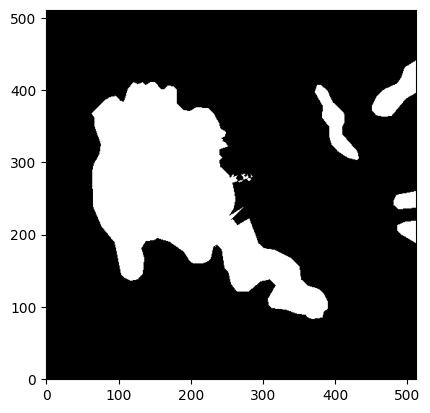

In [7]:

#mask_directory1 = '/media/ExtHDD1/suncharts_mask2_/'

mask_directory1 = '/media/storage/development/test_pole/'


mask = cv2.imread(mask_directory1+"1_0_sch_19590102_0737_kkkk.png.png", 0)

plt.imshow(mask,origin='lower',cmap='gray')  
print("Pixel values in the mask are: ", np.unique(mask))

In [ ]:
# Step 7: Run the next processing stage.
list = []


image_directory1 = '/media//ExtHDD1/sunchart_pole_inc/'

images_1 = sorted(os.listdir(image_directory1))

for k,image_name in enumerate(images_1):

    image = cv2.imread(image_directory1+image_name, cv2.COLOR_BGR2RGB)
    list.append(np.array(image))

In [ ]:
# Step 8: Run the next processing stage.
mask_dataset =[]


mask_directory1 = '/media/ExtHDD1/sunchart_mask_pole_inc/'

masks_1 = sorted(os.listdir(mask_directory1))

for k,image_name in enumerate(masks_1):
    mask = cv2.imread(mask_directory1+image_name, 0)
    mask_dataset.append(np.array(mask))

In [7]:
# Step 9: Run the next processing stage.
images = np.array(list)

In [8]:
# Step 10: Run the next processing stage.
masks_ = np.array(mask_dataset)
masks = np.expand_dims(masks_, -1)

In [9]:
# Step 11: Run the next processing stage.
masks[masks == 194] = 1

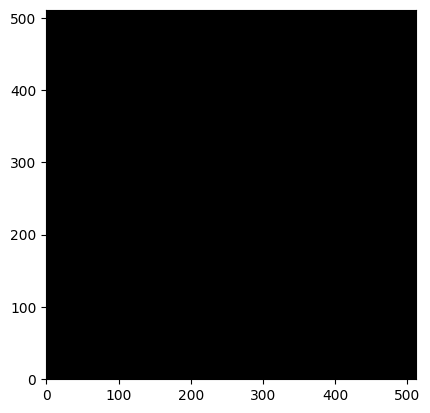

In [10]:
# Step 12: Visualise intermediate or final results.
plt.imshow(masks[2],origin='lower',cmap='gray')

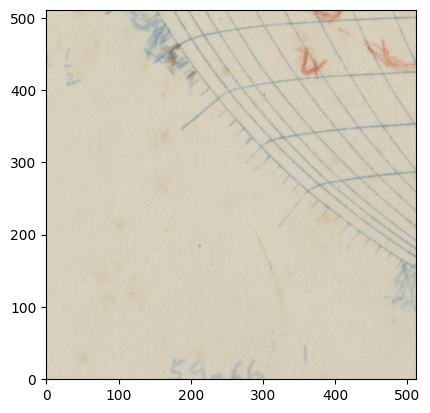

In [11]:
# Step 13: Visualise intermediate or final results.
plt.imshow(images[2],origin='lower',cmap='gray')

In [17]:
# Step 14: Run the next processing stage.
print(np.min(masks[20]))

0


In [10]:
# Step 15: Run the next processing stage.
print("Pixel values in the mask are: ", np.unique(masks))

Pixel values in the mask are:  [0 1]


In [10]:
#Define the model
%env SM_FRAMEWORK=tf.keras
import segmentation_models as sm

env: SM_FRAMEWORK=tf.keras
Segmentation Models: using `tf.keras` framework.


In [11]:
# Step 17: Run the next processing stage.
BACKBONE = 'resnet34'#resnet34
preprocess_input1 = sm.get_preprocessing(BACKBONE)

In [12]:
# preprocess input
images1=preprocess_input1(images)
print(images1.shape)

(7875, 512, 512, 3)


In [13]:
# Step 19: Import dependencies and initialise this stage.
import random
import numpy as np
image_number = random.randint(0, len(images1))
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images1, masks, test_size = 0.24,random_state = 42)#0.25
print(X_train.shape)
print(X_test.shape)

(5985, 512, 512, 3)
(1890, 512, 512, 3)


In [14]:
# Step 20: Import dependencies and initialise this stage.
import tensorflow as tf
from tensorflow import keras

In [ ]:
# Step 21: Import dependencies and initialise this stage.
seed=24#24
from keras.preprocessing.image import ImageDataGenerator

img_data_gen_args = dict(rotation_range=90,
                     width_shift_range=0.3,
                     height_shift_range=0.3,
                     shear_range=0.5,
                     zoom_range=0.3,
                     horizontal_flip=True,
                     vertical_flip=True,
                     fill_mode='reflect')

mask_data_gen_args = dict(rotation_range=90,
                     width_shift_range=0.3,
                     height_shift_range=0.3,
                     shear_range=0.5,
                     zoom_range=0.3,
                     horizontal_flip=True,
                     vertical_flip=True,
                     fill_mode='reflect',
                     preprocessing_function = lambda x: np.where(x>0, 1, 0).astype(x.dtype)) #Binarize the output again. 

image_data_generator = ImageDataGenerator(**img_data_gen_args)
image_data_generator.fit(X_train,augment=True, seed=seed)

image_generator = image_data_generator.flow(X_train,batch_size=32,seed=seed)
valid_img_generator = image_data_generator.flow(X_test, batch_size=32,seed=seed)


mask_data_generator = ImageDataGenerator(**mask_data_gen_args)
mask_data_generator.fit(y_train, augment=True, seed=seed)
mask_generator = mask_data_generator.flow(y_train,batch_size=32, seed=seed)
valid_mask_generator = mask_data_generator.flow(y_test,batch_size=32,seed=seed)


def my_image_mask_generator(image_generator, mask_generator):
    train_generator = zip(image_generator, mask_generator)
    for (img, mask) in train_generator:
        yield (img, mask)
my_generator = my_image_mask_generator(image_generator, mask_generator)

validation_datagen = my_image_mask_generator(valid_img_generator,valid_mask_generator)

In [ ]:
# Step 22: Import dependencies and initialise this stage.
import math
# We take the ceiling because we do not drop the remainder of the batch
compute_steps_per_epoch = lambda my_generator: int(math.ceil(1. * my_generator / 32))
 
steps_per_epoch = compute_steps_per_epoch(5985)
val_steps = compute_steps_per_epoch(1890)
print(steps_per_epoch)
print(val_steps)

188
60


In [18]:
# Step 23: Import dependencies and initialise this stage.
import tensorflow as tf
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.allow_growth=True
sess = tf.compat.v1.Session(config=config)

2025-05-12 14:07:31.741112: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 0 with properties: 
pciBusID: 0000:21:00.0 name: Quadro RTX 8000 computeCapability: 7.5
coreClock: 1.77GHz coreCount: 72 deviceMemorySize: 47.46GiB deviceMemoryBandwidth: 625.94GiB/s
2025-05-12 14:07:31.741414: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 1 with properties: 
pciBusID: 0000:15:00.0 name: NVIDIA GeForce GT 710 computeCapability: 3.5
coreClock: 0.954GHz coreCount: 1 deviceMemorySize: 1.95GiB deviceMemoryBandwidth: 11.92GiB/s
2025-05-12 14:07:31.742494: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1856] Ignoring visible gpu device (device: 1, name: NVIDIA GeForce GT 710, pci bus id: 0000:15:00.0, compute capability: 3.5) with core count: 1. The minimum required count is 8. You can adjust this requirement with the env var TF_MIN_GPU_MULTIPROCESSOR_COUNT.
2025-05-12 14:07:31.742506: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1871] Adding vi

In [ ]:
# define model
model = sm.Unet(BACKBONE, encoder_weights='imagenet',encoder_freeze=True)
model.compile('Adam', loss=sm.losses.bce_jaccard_loss, metrics=[sm.metrics.iou_score]) 
print(model.summary())

2025-05-12 19:52:05.159245: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcuda.so.1
2025-05-12 19:52:05.238495: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 0 with properties: 
pciBusID: 0000:21:00.0 name: Quadro RTX 8000 computeCapability: 7.5
coreClock: 1.77GHz coreCount: 72 deviceMemorySize: 47.46GiB deviceMemoryBandwidth: 625.94GiB/s
2025-05-12 19:52:05.238864: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 1 with properties: 
pciBusID: 0000:15:00.0 name: NVIDIA GeForce GT 710 computeCapability: 3.5
coreClock: 0.954GHz coreCount: 1 deviceMemorySize: 1.95GiB deviceMemoryBandwidth: 11.92GiB/s
2025-05-12 19:52:05.239001: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0
2025-05-12 19:52:05.255396: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublas.so.11
202

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
data (InputLayer)               [(None, None, None,  0                                            
__________________________________________________________________________________________________
bn_data (BatchNormalization)    (None, None, None, 3 9           data[0][0]                       
__________________________________________________________________________________________________
zero_padding2d (ZeroPadding2D)  (None, None, None, 3 0           bn_data[0][0]                    
__________________________________________________________________________________________________
conv0 (Conv2D)                  (None, None, None, 6 9408        zero_padding2d[0][0]             
____________________________________________________________________________________________

In [ ]:
# Step 25: Train the configured model.
history = model.fit(my_generator, validation_data=validation_datagen, steps_per_epoch=50,validation_steps=50,batch_size=32, epochs=60,shuffle=True) 
model.save('/home/dibya/plage_suncharts_manual_pole.h5') 

2025-05-12 19:52:41.301111: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)
2025-05-12 19:52:41.322997: I tensorflow/core/platform/profile_utils/cpu_utils.cc:114] CPU Frequency: 3699850000 Hz


Epoch 1/60


2025-05-12 19:52:44.430805: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudnn.so.8
2025-05-12 19:52:45.201764: I tensorflow/stream_executor/cuda/cuda_dnn.cc:359] Loaded cuDNN version 8202
2025-05-12 19:52:46.288562: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublas.so.11
2025-05-12 19:52:47.231818: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublasLt.so.11


50/50 [==============================] - 166s 3s/step - loss: 0.9882 - iou_score: 0.1946 - val_loss: 1.4291 - val_iou_score: 0.0940
Epoch 2/60
50/50 [==============================] - 152s 3s/step - loss: 0.6746 - iou_score: 0.4131 - val_loss: 0.9923 - val_iou_score: 0.2394
Epoch 3/60
50/50 [==============================] - 153s 3s/step - loss: 0.5783 - iou_score: 0.5048 - val_loss: 0.9509 - val_iou_score: 0.2846
Epoch 4/60
50/50 [==============================] - 152s 3s/step - loss: 0.5354 - iou_score: 0.5301 - val_loss: 0.8743 - val_iou_score: 0.2198
Epoch 5/60
50/50 [==============================] - 152s 3s/step - loss: 0.5205 - iou_score: 0.5582 - val_loss: 0.6805 - val_iou_score: 0.4026
Epoch 6/60
50/50 [==============================] - 153s 3s/step - loss: 0.4957 - iou_score: 0.5782 - val_loss: 0.7773 - val_iou_score: 0.3350
Epoch 7/60
50/50 [==============================] - 154s 3s/step - loss: 0.4774 - iou_score: 0.5973 - val_loss: 0.5811 - val_iou_score: 0.5046
Epoch 8/60

/home/dibya/.local/lib/python3.8/site-packages/tensorflow/python/keras/utils/generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '


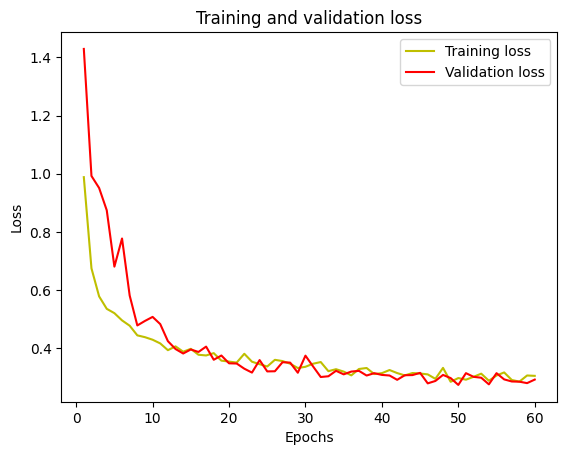

In [18]:
#plot the training and validation accuracy and loss at each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Step 27: Run the next processing stage.
acc = history.history['iou_score']
val_acc = history.history['val_iou_score']

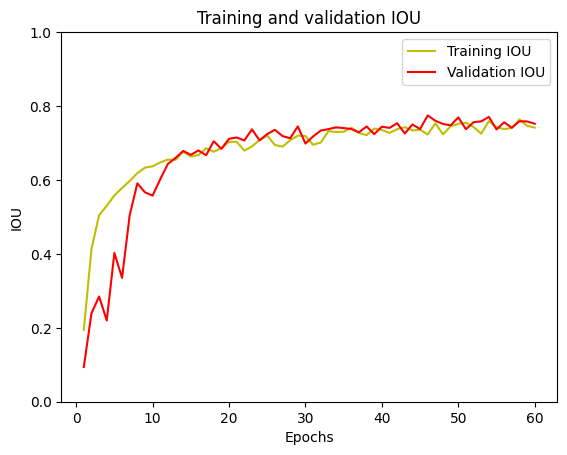

In [20]:
# Step 28: Visualise intermediate or final results.
plt.plot(epochs, acc, 'y', label='Training IOU')
plt.plot(epochs, val_acc, 'r', label='Validation IOU')
plt.title('Training and validation IOU')
plt.xlabel('Epochs')
plt.ylabel('IOU')
plt.ylim(0,1)
plt.legend()
plt.show()

In [21]:
# Step 29: Import dependencies and initialise this stage.
import h5py
with h5py.File(f"/home/dibya/iou_plage_idnt.h5", "w") as f:    
            
            mask_dataset = f.create_dataset("mask",data=epochs)
            # Add header information as attributes
            mask_dataset.attrs["epochs"] = epochs  # Current timestamp
            mask_dataset.attrs["loss"] = loss  # Assuming center is a tuple (x, y)
            mask_dataset.attrs["val_loss"] = val_loss  # Assuming radius is a float or int
            mask_dataset.attrs["acc"] = acc
            mask_dataset.attrs["val_acc"] = val_acc